<a href="https://colab.research.google.com/github/fboldt/aulasann/blob/main/aula09a_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Processamento de Linguagem Natural

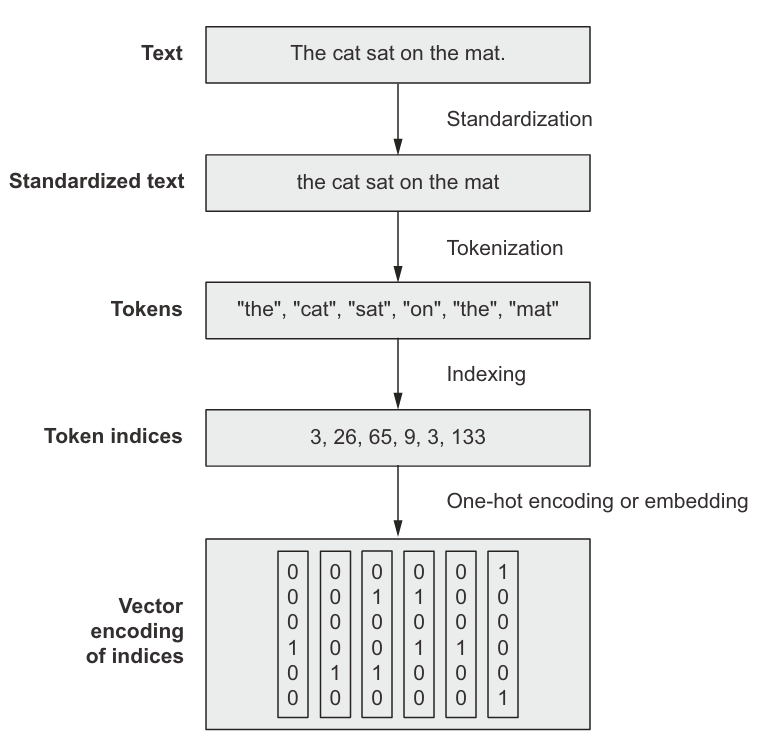

In [8]:
import tensorflow as tf
import re
import string

def standardize(input_data):
  lowercase = tf.strings.lower(input_data)
  return tf.strings.regex_replace(lowercase,
                                  '[%s]' % re.escape(string.punctuation),
                                  '')

text = "The cat sat on the mat."
standardize(text)

<tf.Tensor: shape=(), dtype=string, numpy=b'the cat sat on the mat'>

In [15]:
def tokenize(input_data):
  return tf.strings.split(input_data, ' ')

text = "The cat sat on the mat."
tokenize(text)

<tf.Tensor: shape=(6,), dtype=string, numpy=array([b'The', b'cat', b'sat', b'on', b'the', b'mat.'], dtype=object)>

In [16]:
text = "The cat sat on the mat."

vocabulary = {}
standardize_text = standardize(text)
tokens = tokenize(standardize_text)
for token in tokens:
  word = token.numpy().decode('utf-8')
  if word not in vocabulary:
    vocabulary[word] = len(vocabulary)
print(vocabulary)

{'the': 0, 'cat': 1, 'sat': 2, 'on': 3, 'mat': 4}


In [25]:
import numpy as np

def one_hot_encode_token(token):
  vector = np.zeros(len(vocabulary))
  index = vocabulary[token]
  vector = tf.one_hot(index, len(vocabulary))
  return vector

one_hot_encode_token("cat")

<tf.Tensor: shape=(5,), dtype=float32, numpy=array([0., 1., 0., 0., 0.], dtype=float32)>

In [27]:
one_hot_encode_token("dog")

KeyError: 'dog'

In [33]:
import string

class Vectorizer():
  def standardize(self, text):
    lowercase = text.lower()
    return "".join(char for char in lowercase if char not in string.punctuation)

  def tokenize(self, text):
    text = self.standardize(text)
    return text.split()

  def make_vocabulary(self, dataset):
    self.vocabulary = {"": 0, "[UNK]": 1}
    for text in dataset:
      tokens = self.tokenize(text)
      for token in tokens:
        if token not in self.vocabulary:
          self.vocabulary[token] = len(self.vocabulary)
    self.inverse_vocabulary = dict((v, k) for k, v in self.vocabulary.items())

  def encode(self, text):
    tokens = self.tokenize(text)
    return [self.vocabulary.get(token, 1) for token in tokens]

  def decode(self, tokens):
    return " ".join(self.inverse_vocabulary.get(token, "[UNK]") for token in tokens)

vectorizer = Vectorizer()
dataset = [
    "The cat sat on the mat.",
    "The dog sat on the rug.",
    "The cat sat on the rug mat.",
]
vectorizer.make_vocabulary(dataset)
encoded_sentence = vectorizer.encode("The hamster sat on the floor.")
print(encoded_sentence)
decoded_sentence = vectorizer.decode(encoded_sentence)
print(decoded_sentence)

[2, 1, 4, 5, 2, 1]
the [UNK] sat on the [UNK]


In [34]:
from tensorflow.keras.layers import TextVectorization
text_vectorization = TextVectorization(output_mode="int")
text_vectorization.adapt(dataset)
text_vectorization(dataset)

<tf.Tensor: shape=(3, 7), dtype=int64, numpy=
array([[2, 7, 3, 4, 2, 6, 0],
       [2, 8, 3, 4, 2, 5, 0],
       [2, 7, 3, 4, 2, 5, 6]])>

In [35]:
text_vectorization("The hamster sat on the floor.")

<tf.Tensor: shape=(6,), dtype=int64, numpy=array([2, 1, 3, 4, 2, 1])>

In [36]:
text_vectorization.get_vocabulary()

['',
 '[UNK]',
 np.str_('the'),
 np.str_('sat'),
 np.str_('on'),
 np.str_('rug'),
 np.str_('mat'),
 np.str_('cat'),
 np.str_('dog')]